# 01 — Carga y EDA inicial

Carga de `trainHistory.csv`, `testHistory.csv`, `offers.csv`, descripción de cada archivo, balance de la variable objetivo `repeater`, y cruce train x offers.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from carga import cargar_offers, cargar_test, cargar_train
from config import FIGURES_DIR, TABLES_DIR, TRAIN_OFFERS_PATH

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", None)

## 1. Carga de los archivos

In [2]:
train = cargar_train()
test = cargar_test()
offers = cargar_offers()

print("train:", train.shape)
print("test:", test.shape)
print("offers:", offers.shape)

train: (160057, 7)
test: (151484, 5)
offers: (37, 6)


## 2. Observaciones, variables y tipos de cada archivo

In [3]:
resumen_shapes = pd.DataFrame(
    {
        "archivo": ["trainHistory", "testHistory", "offers"],
        "n_observaciones": [train.shape[0], test.shape[0], offers.shape[0]],
        "n_variables": [train.shape[1], test.shape[1], offers.shape[1]],
    }
)
resumen_shapes.to_csv(TABLES_DIR / "01_resumen_shapes.csv", index=False)
resumen_shapes

,archivo,n_observaciones,n_variables
0,trainHistory,160057,7
1,testHistory,151484,5
2,offers,37,6


In [4]:
train.dtypes.rename("dtype").to_frame()

,dtype
id,int64
chain,int32
offer,int32
market,int32
repeattrips,int32
repeater,bool
offerdate,datetime64[us]


In [5]:
test.dtypes.rename("dtype").to_frame()

,dtype
id,int64
chain,int32
offer,int32
market,int32
offerdate,datetime64[us]


In [6]:
offers.dtypes.rename("dtype").to_frame()

,dtype
offer,int32
category,int32
quantity,int32
company,int64
offervalue,float64
brand,int64


## 3. Balance de la variable objetivo `repeater`

`repeater = True` si `repeattrips > 0`, es decir, el cliente volvió a comprar el producto ofertado después de redimir el cupón.

In [7]:
balance_repeater = train["repeater"].value_counts(normalize=True).rename("proporcion").to_frame()
balance_repeater["conteo"] = train["repeater"].value_counts()
balance_repeater.to_csv(TABLES_DIR / "01_balance_repeater.csv")
balance_repeater

,proporcion,conteo
repeater,,
False,0.728609,116619
True,0.271391,43438


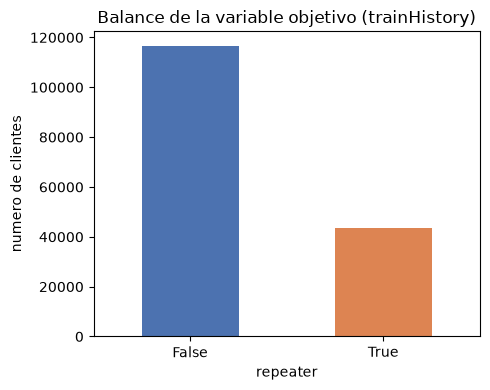

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
train["repeater"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_xlabel("repeater")
ax.set_ylabel("numero de clientes")
ax.set_title("Balance de la variable objetivo (trainHistory)")
ax.set_xticklabels(["False", "True"], rotation=0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_balance_repeater.png", dpi=150)
plt.show()

## 4. Cruce `trainHistory` con `offers`

Cada oferta trae la categoria, marca y compania del producto ofertado, y el valor del descuento (`offervalue`) y las unidades requeridas (`quantity`) para activarlo.

In [9]:
train_offers = train.merge(offers, on="offer", how="left")
print(train_offers.shape)
train_offers.head()

(160057, 12)


,id,chain,offer,market,repeattrips,repeater,offerdate,category,quantity,company,offervalue,brand
0,86246,205,1208251,34,5,True,2013-04-24,2202,1,104460040,2.00,3718
1,86252,205,1197502,34,16,True,2013-03-27,3203,1,106414464,0.75,13474
2,12682470,18,1197502,11,0,False,2013-03-28,3203,1,106414464,0.75,13474
3,12996040,15,1197502,9,0,False,2013-03-25,3203,1,106414464,0.75,13474
4,13089312,15,1204821,9,0,False,2013-04-01,5619,1,107717272,1.50,102504


In [10]:
top_categorias = train_offers["category"].value_counts().rename("n_ofertas").to_frame()
top_categorias.to_csv(TABLES_DIR / "01_categorias_ofertadas.csv")
top_categorias

,n_ofertas
category,
3203,45652
9909,22147
2119,18767
2202,18421
4401,15008
6202,9056
5616,7293
5558,6974
1726,6323


In [11]:
top_marcas = train_offers["brand"].value_counts().rename("n_ofertas").to_frame()
top_marcas.to_csv(TABLES_DIR / "01_marcas_ofertadas.csv")
top_marcas.head(10)

,n_ofertas
brand,
13474,45652
6926,18767
3718,18421
28840,15337
13791,15008
7668,10705
64486,9056
15889,7293
5072,6974


In [12]:
top_companias = train_offers["company"].value_counts().rename("n_ofertas").to_frame()
top_companias.to_csv(TABLES_DIR / "01_companias_ofertadas.csv")
top_companias

,n_ofertas
company,
106414464,45652
104460040,29126
108079383,18767
1089520383,15337
105100050,15008
1087744888,9056
104610040,7293
107120272,6974
107127979,6810


In [13]:
resumen_offervalue_quantity = train_offers[["offervalue", "quantity"]].describe()
resumen_offervalue_quantity.to_csv(TABLES_DIR / "01_resumen_offervalue_quantity.csv")
resumen_offervalue_quantity

,offervalue,quantity
count,160057.000000,160057.0
mean,1.255323,1.0
std,0.524645,0.0
min,0.750000,1.0
25%,0.750000,1.0
50%,1.000000,1.0
75%,1.500000,1.0
max,3.000000,1.0


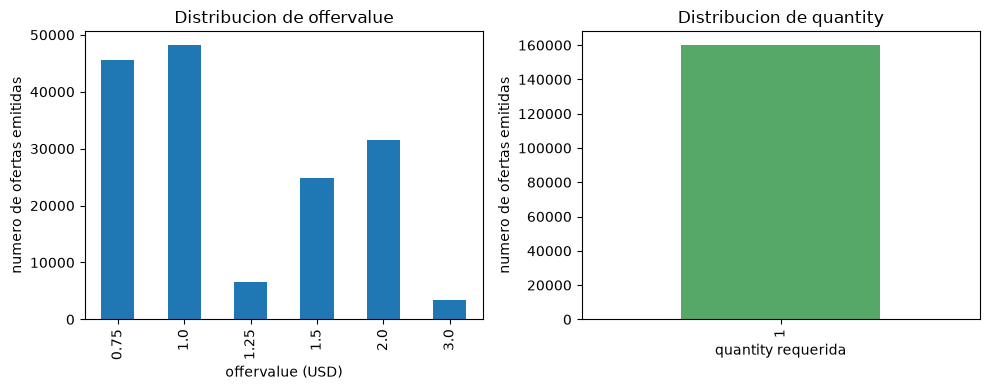

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train_offers["offervalue"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Distribucion de offervalue")
axes[0].set_xlabel("offervalue (USD)")
axes[0].set_ylabel("numero de ofertas emitidas")

train_offers["quantity"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Distribucion de quantity")
axes[1].set_xlabel("quantity requerida")
axes[1].set_ylabel("numero de ofertas emitidas")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_offervalue_quantity.png", dpi=150)
plt.show()

## 5. Guardar el cruce train x offers

In [15]:
train_offers.to_csv(TRAIN_OFFERS_PATH, index=False)
print(f"Guardado en {TRAIN_OFFERS_PATH} con shape {train_offers.shape}")

Guardado en C:\Users\anna2\Desktop\UVG\Data Science\Proyecto-02-Data-Science\data\processed\train_offers.csv con shape (160057, 12)
